# Локальная валидационная кампания CARS (7 пар модель×датасет)

**Дата:** 2026-06-04 · **Среда:** локальный прогон на RTX 3090, CUDAExecutionProvider, onnxruntime 1.24, Python 3.13, `.venv`.

**Цель:** честное локальное переизмерение стека моделей (NGC TAO + кастомный color + продакшн-стек RU nomeroff) против прежнего удалённого прогона qudata. Удалённые числа (включая nomeroff PASS) — только ориентир, локально не воспроизведены.

**7 пар:**
1. `trafficcamnet` × BDD100K — детекция
2. `vehicletypenet` × Stanford Cars — классификация типа кузова
3. `vehiclemakenet` × VMMRdb — классификация марки
4. `color` (bae_model_f3) × MAD-Cars — классификация цвета
5. `nomeroff_lpd` × AUTO.RIA detection — детекция номера (RU)
6. `nomeroff_ocr` × AUTO.RIA OCR — распознавание номера (RU)
7. `facedetect` (FaceNet) × WIDER FACE — детекция лиц

**Итог: 0 PASS / 4 FAIL / 2 DEFERRED / 1 UNDEF.**

## Как воспроизвести

Каждая пара запускается контроллером (НЕ из этого ноутбука):

```bash
.venv/bin/python deploy/scripts/run_local.py --models trafficcamnet     # ~3 мин, 10000 img
.venv/bin/python deploy/scripts/run_local.py --models vehicletypenet    # ~39 с
.venv/bin/python deploy/scripts/run_local.py --models vehiclemakenet    # ~11.5 мин, 243519 img (ДОЛГО)
.venv/bin/python deploy/scripts/run_local.py --models color             # ~47 с
.venv/bin/python deploy/scripts/run_local.py --models nomeroff_lpd      # DEFERRED: import nomeroff_net падает (нет modelhub_client)
.venv/bin/python deploy/scripts/run_local.py --models nomeroff_ocr      # DEFERRED: тот же блокер
.venv/bin/python deploy/scripts/run_local.py --models facedetect        # UNDEF: FaceNet ONNX недоступен
```

**Важно:** прогоны `vehiclemakenet` и `trafficcamnet` длительные (минуты). `nomeroff_*` отложены (DEFERRED), `facedetect` неопределён (UNDEF). Поэтому **этот ноутбук НЕ перезапускает модели**, а **читает предвычисленные** `results/<model>/metrics.json`.

In [1]:
import json
from pathlib import Path

# Корень репозитория: ноутбук лежит в notebooks/, поднимаемся на уровень выше.
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = REPO / "results"

# Порядок пар + удобочитаемые имена датасетов.
PAIRS = [
    ("trafficcamnet",  "BDD100K val"),
    ("vehicletypenet", "Stanford Cars (TRAIN)"),
    ("vehiclemakenet", "VMMRdb"),
    ("color",          "MAD-Cars"),
    ("nomeroff_lpd",   "AUTO.RIA detection"),
    ("nomeroff_ocr",   "AUTO.RIA OCR"),
    ("facedetect",     "WIDER FACE val"),
]

def load_metrics(model):
    p = RESULTS / model / "metrics.json"
    if not p.exists():
        return {}
    with open(p, encoding="utf-8") as f:
        return json.load(f)

def verdict_and_keys(model, d):
    """Робастно к форме measured / deferred / UNDEF (везде .get)."""
    status = d.get("status")  # 'deferred' / 'UNDEF' у отложенных
    m = d.get("metrics", {})
    thr = d.get("thresholds", {})

    if status == "deferred":
        prior = d.get("prior_remote_qudata", {})
        # показываем удалённый ориентир, явно помеченный
        keys = "; ".join(f"{k}={v}" for k, v in prior.items() if k != "note")
        return "DEFERRED", f"локально НЕ измерено (удал. qudata: {keys})"
    if status == "UNDEF" or status == "undef":
        return "UNDEF", "модель недоступна (ONNX не получен), данные+код готовы"

    # measured: вердикт = PASS только если ВСЕ пороги PASS, иначе FAIL
    statuses = [t.get("status") for t in thr.values()] if thr else []
    if statuses and all(s == "PASS" for s in statuses):
        verdict = "PASS"
    elif statuses:
        verdict = "FAIL"
    else:
        verdict = "?"

    # ключевые метрики по семействам
    if "top1_accuracy" in m:
        keys = f"Top-1={m.get('top1_accuracy')}, Top-3={m.get('top3_accuracy')}"
        if "best_group_min" in m:
            keys += f", best_group_min={m.get('best_group_min')}, challenging_group_min={m.get('challenging_group_min')}"
    elif "precision" in m:
        keys = f"car P={m.get('precision')}, R={m.get('recall')}, F1={m.get('f1')}"
    else:
        keys = "—"
    return verdict, keys

rows = []
for model, dataset in PAIRS:
    d = load_metrics(model)
    verdict, keys = verdict_and_keys(model, d)
    rows.append({"model": model, "dataset": dataset, "key_metrics": keys, "verdict": verdict})

try:
    import pandas as pd
    df = pd.DataFrame(rows, columns=["model", "dataset", "key_metrics", "verdict"])
    print(df.to_string(index=False))
    tally = df["verdict"].value_counts().to_dict()
except Exception:
    df = None
    for r in rows:
        print(f"{r['model']:16s} | {r['dataset']:22s} | {r['verdict']:9s} | {r['key_metrics']}")
    from collections import Counter
    tally = dict(Counter(r["verdict"] for r in rows))

print()
print("Tally:", tally)


         model               dataset                                                                      key_metrics  verdict
 trafficcamnet           BDD100K val                                                car P=0.3909, R=0.2584, F1=0.3111     FAIL
vehicletypenet Stanford Cars (TRAIN)                                                       Top-1=0.3549, Top-3=0.6932     FAIL
vehiclemakenet                VMMRdb                                                        Top-1=0.4387, Top-3=0.625     FAIL
         color              MAD-Cars     Top-1=0.6205, Top-3=0.8395, best_group_min=0.4793, challenging_group_min=0.0     FAIL
  nomeroff_lpd    AUTO.RIA detection  локально НЕ измерено (удал. qudata: precision=0.9056; recall=0.9221; f1=0.9138) DEFERRED
  nomeroff_ocr          AUTO.RIA OCR локально НЕ измерено (удал. qudata: char_accuracy=0.9995; plate_accuracy=0.9978) DEFERRED
    facedetect        WIDER FACE val                           модель недоступна (ONNX не получен), данные+код 

## Ключевые графики (предвычислены, из `plots/`)

Графики только для измеренных пар (для DEFERRED/UNDEF графиков нет).

=== Color × MAD-Cars — confusion matrix (color_confusion.png) ===


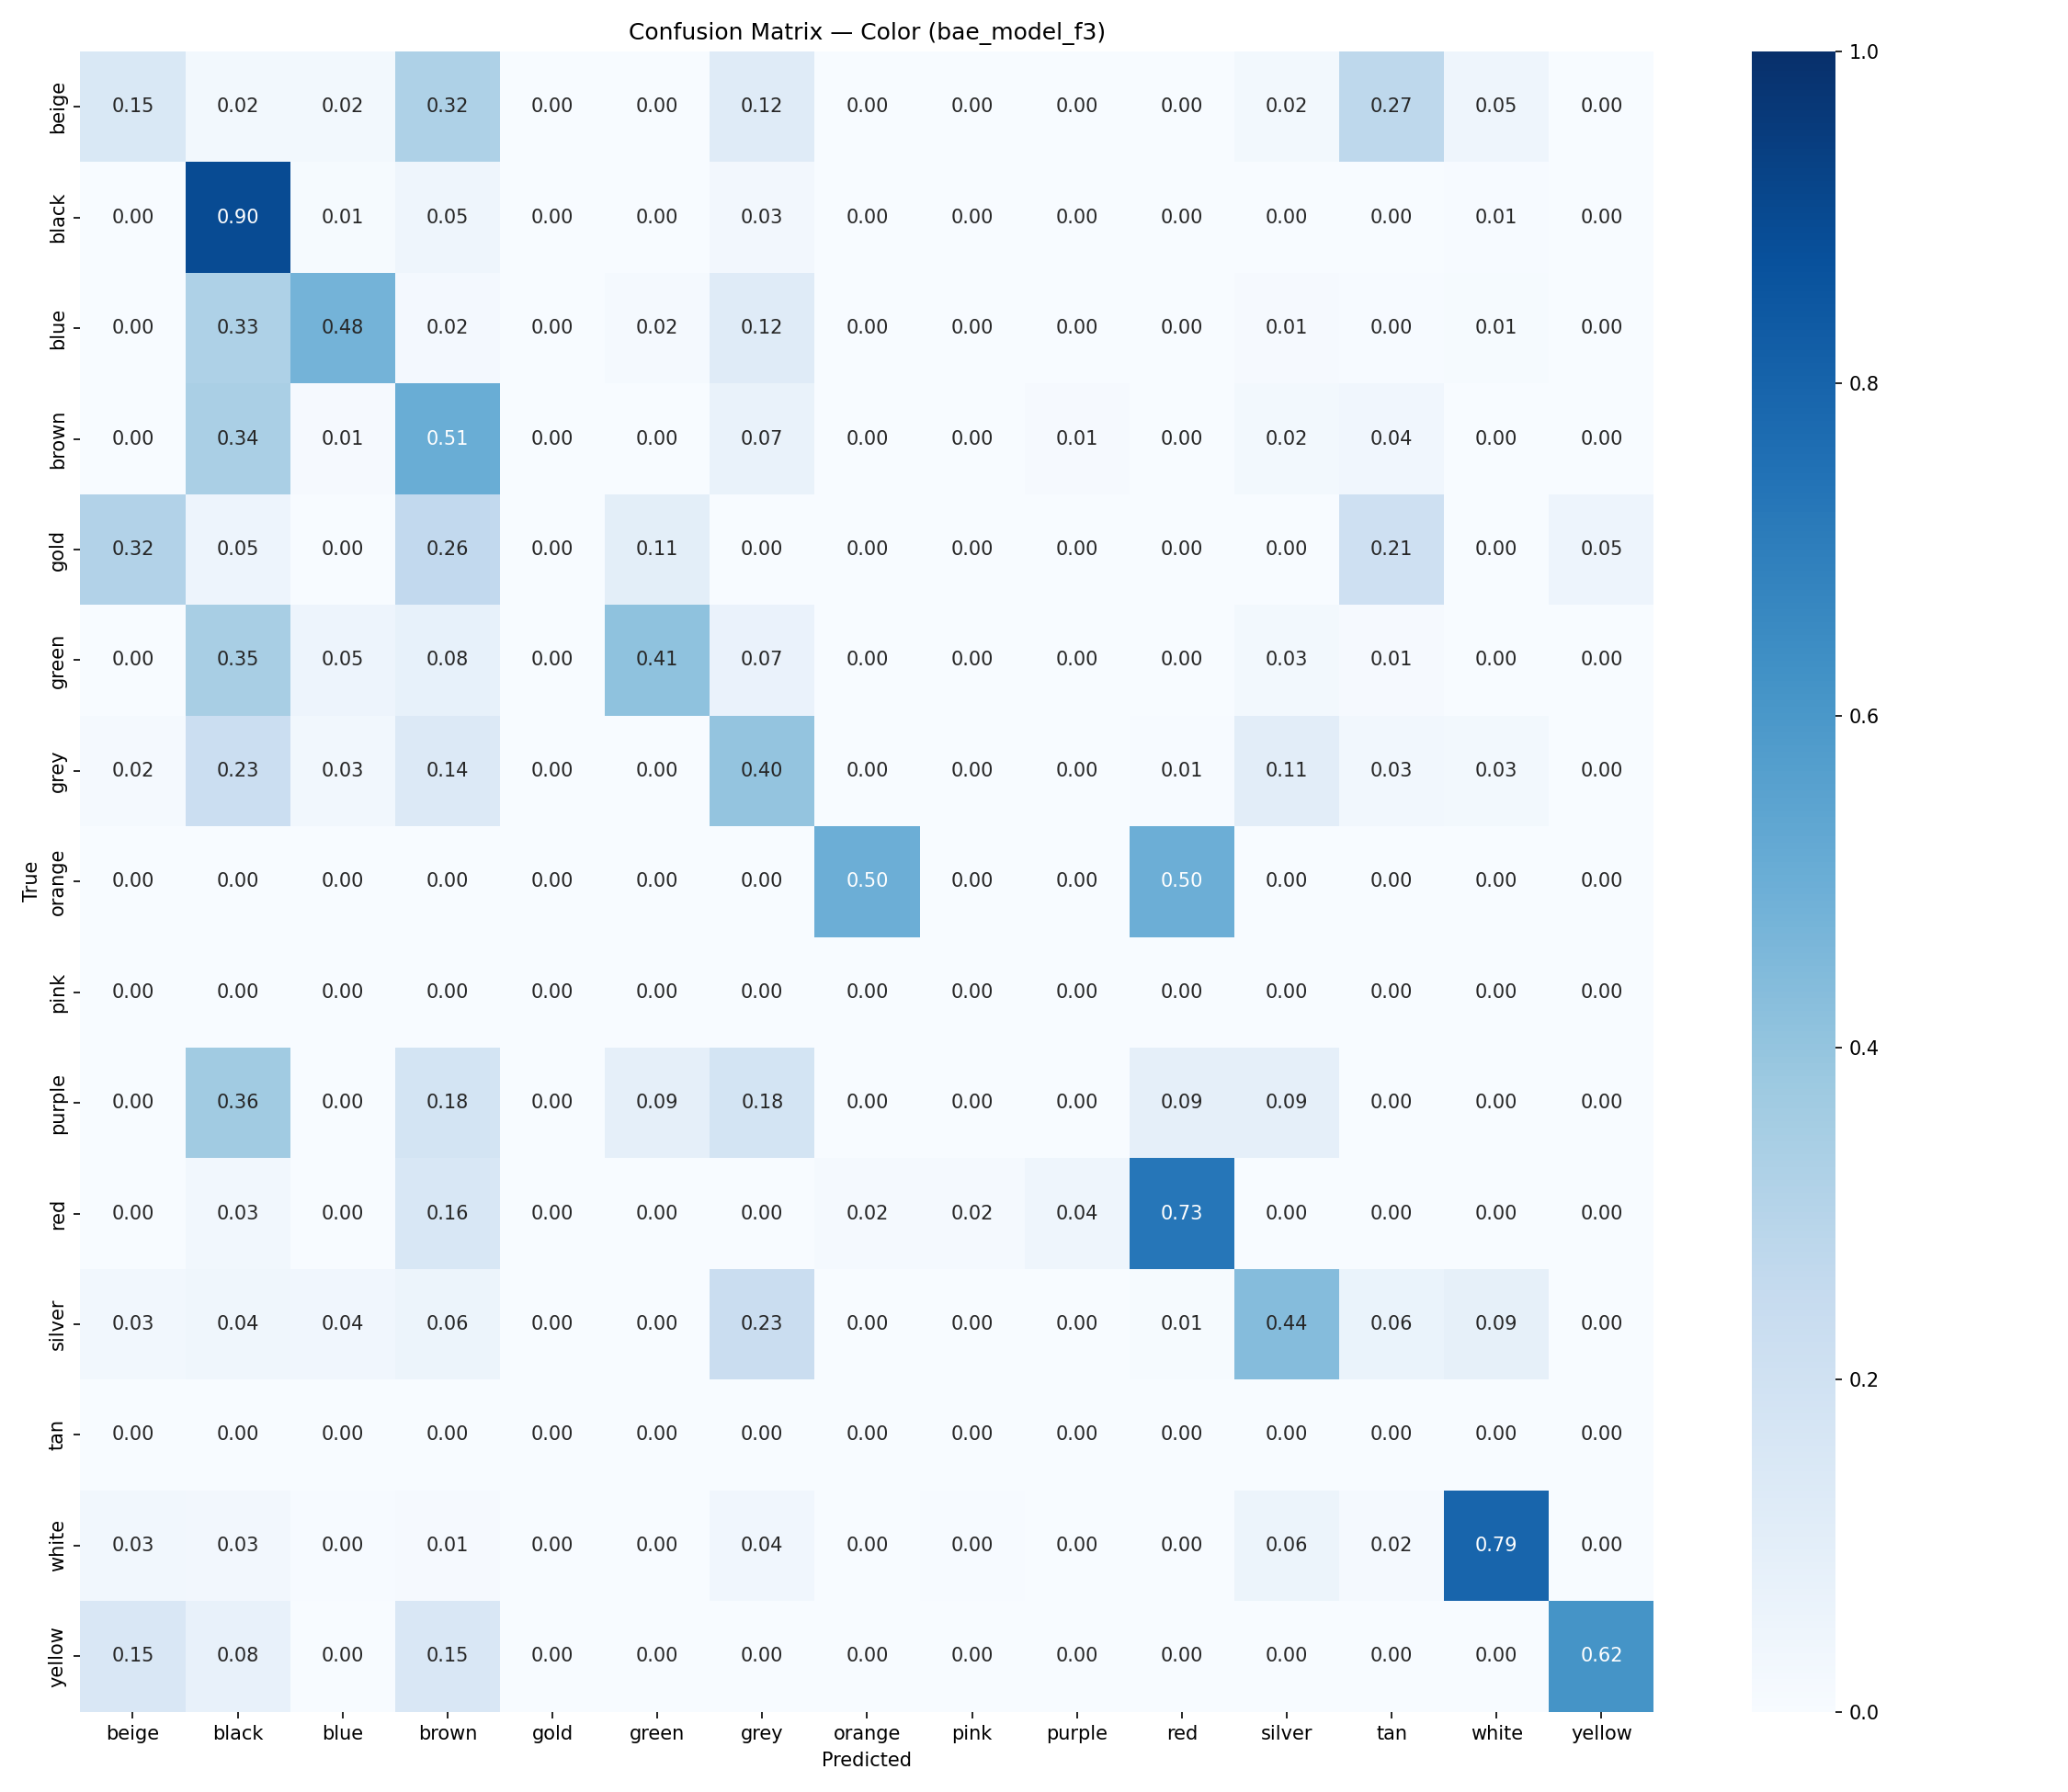

=== Color × MAD-Cars — per-class accuracy (color_per_class.png) ===


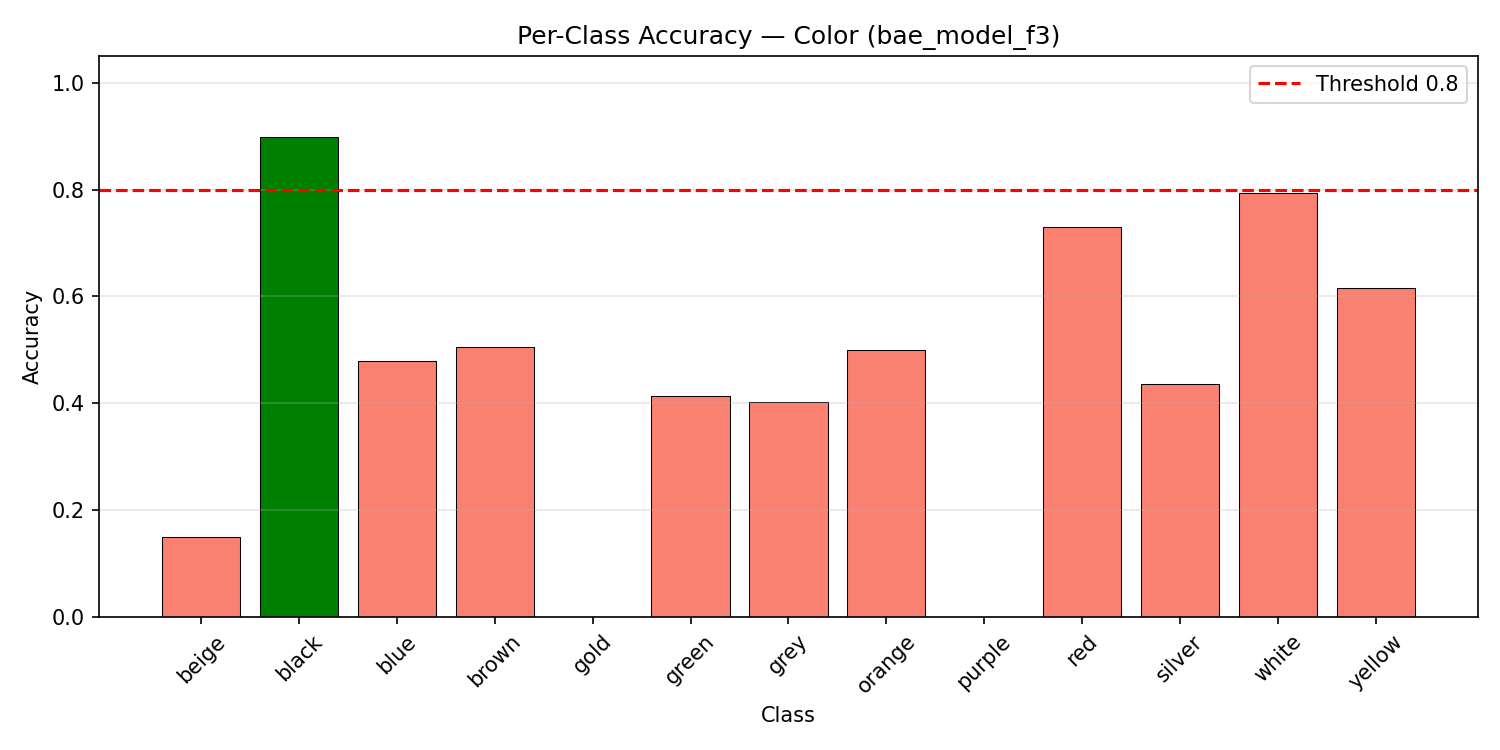

=== VehicleMakeNet × VMMRdb — per-class accuracy (vehiclemakenet_per_class.png) ===


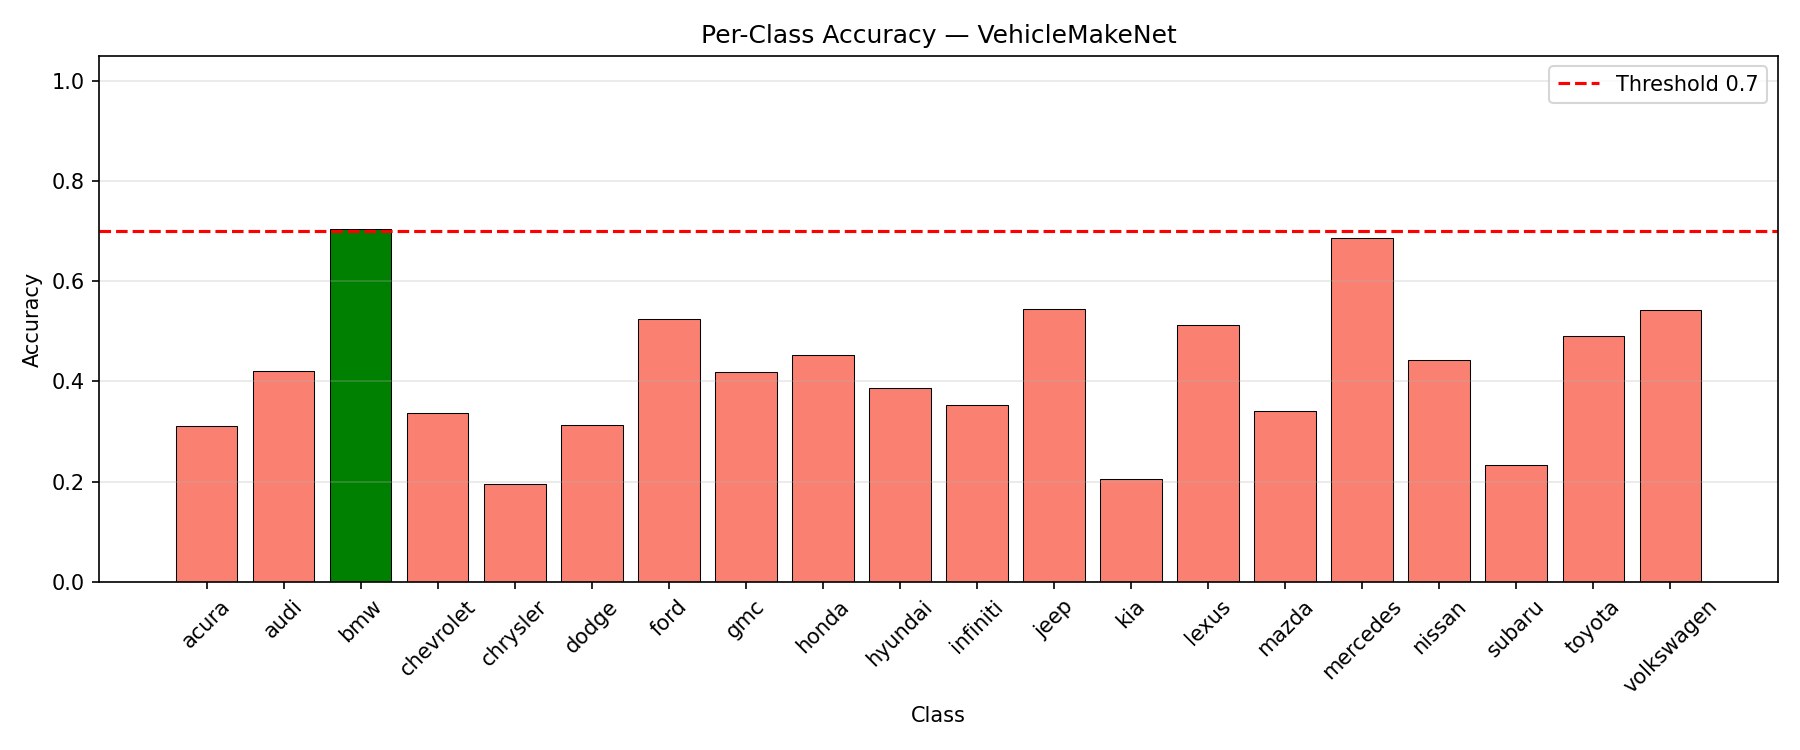

=== VehicleTypeNet × Stanford Cars — confusion matrix (vehicletypenet_confusion.png) ===


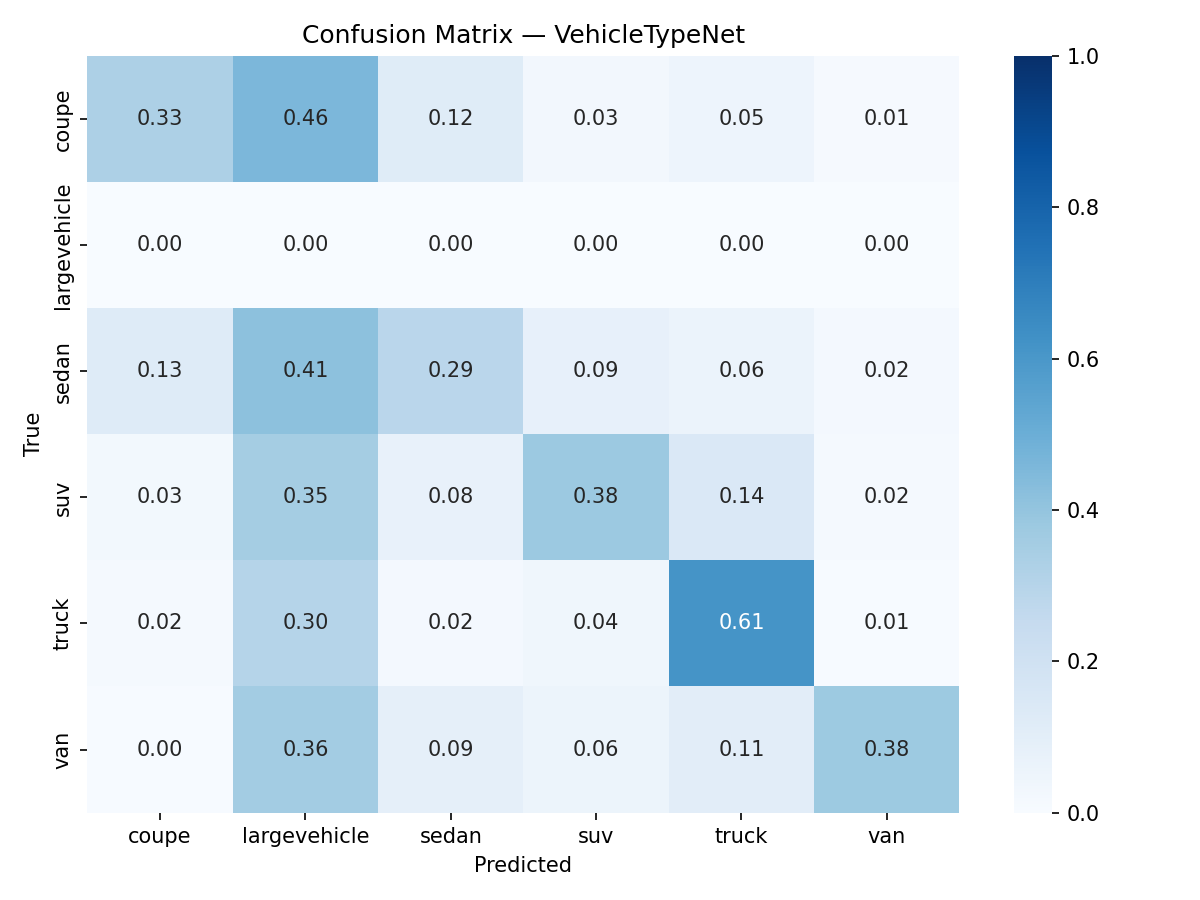

In [2]:
from IPython.display import Image, display

PLOTS = REPO / "plots"
for png, caption in [
    ("color_confusion.png",            "Color × MAD-Cars — confusion matrix"),
    ("color_per_class.png",            "Color × MAD-Cars — per-class accuracy"),
    ("vehiclemakenet_per_class.png",   "VehicleMakeNet × VMMRdb — per-class accuracy"),
    ("vehicletypenet_confusion.png",   "VehicleTypeNet × Stanford Cars — confusion matrix"),
]:
    p = PLOTS / png
    print(f"=== {caption} ({png}) ===")
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f"  [пропущено: {p} не найден]")


## Выводы

**Итог: 0 PASS / 4 FAIL / 2 DEFERRED / 1 UNDEF.**

- **4 FAIL (измерено):** `trafficcamnet`, `vehicletypenet`, `vehiclemakenet`, `color`. Корневая причина — **доменный разрыв**: модели NGC TAO обучены на US/EU-данных и слабы на RU-рынке / разнородных датасетах (дорожные камеры → бортовая съёмка; US-марки; суррогатные/шумные метки типа кузова; трудные/слитые цвета + непроверяемый маппинг меток color). FAIL — валидные окончательные результаты, тюнинг не применялся.
- **2 DEFERRED:** `nomeroff_lpd`, `nomeroff_ocr` — продакшн-стек RU. Локально не воспроизведены из-за упаковки (`import nomeroff_net` падает: нет `modelhub_client` на PyPI). Прежний удалённый прогон qudata давал PASS (LPD P=0.9056/R=0.9221; OCR CharAcc=0.9995/PlateAcc=0.9978) — **только ориентир, локально НЕ воспроизведено**.
- **1 UNDEF:** `facedetect` (FaceNet) — модель недоступна (зашифрованный `.etlt`, нет `tao_converter`, NGC ONNX → 404). Код и данные (WIDER FACE val) готовы — прогон запустится без изменений кода при появлении deployable ONNX.

Полная сводка: `results/SUMMARY.md`. Детали по каждой паре: `results/<model>/EXPERIMENT.md`.